In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA

def hacer_multiples_circulos(n_samples=500, n_circles=3, noise=0.05, random_state=None):
    """
    Genera N círculos concéntricos con ruido

    Parámetros:
        n_samples (int): Número total de puntos
        n_circles (int): Número de círculos (clases)
        noise (float): Desviación estándar del ruido
        random_state (int): Semilla aleatoria

    Salida:
        X (ndarray): Datos (n_samples, 2).
        y (ndarray): Etiquetas (n_samples,).
    """
    if random_state:
        np.random.seed(random_state)

    X_list = []
    y_list = []

    # Puntos por cada círculo
    n_per_circle = n_samples // n_circles

    # Creamos radios equidistantes desde 0.2 hasta 1.0
    # Ejemplo con 3 círculos: [0.2, 0.6, 1.0]
    radio = np.linspace(0.2, 1.0, n_circles)

    for i, r in enumerate(radio):
        # Generamos ángulos (0 a 2*pi)
        theta = np.linspace(0, 2 * np.pi, n_per_circle, endpoint=False)

        # Coordenadas
        x = r * np.cos(theta)
        y = r * np.sin(theta)

        # Apilamos y guardamos
        circle_data = np.stack([x, y], axis=1)
        X_list.append(circle_data)
        y_list.append(np.full(n_per_circle, i)) # Etiqueta i (0, 1, 2...)

    # Unimos todo
    X = np.vstack(X_list)
    y = np.hstack(y_list)

    # Añadimos Ruido
    if noise:
        X += np.random.normal(scale=noise, size=X.shape)

    # Mezclamos
    indices = np.random.permutation(len(X))
    return X[indices], y[indices]

In [2]:
# Configuración
N_CIRCLES = 3
N_SAMPLES = 600

# Generamos datos
X, y = hacer_multiples_circulos(n_samples=N_SAMPLES, n_circles=N_CIRCLES, noise=0.05, random_state=42)

# Aplicamos PCA Lineal
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Aplicamos Kernel PCA (RBF)
# gamma=15 suele funcionar bien para separar círculos apretados
kpca = KernelPCA(n_components=2, kernel="rbf", gamma=15)
X_kpca = kpca.fit_transform(X)

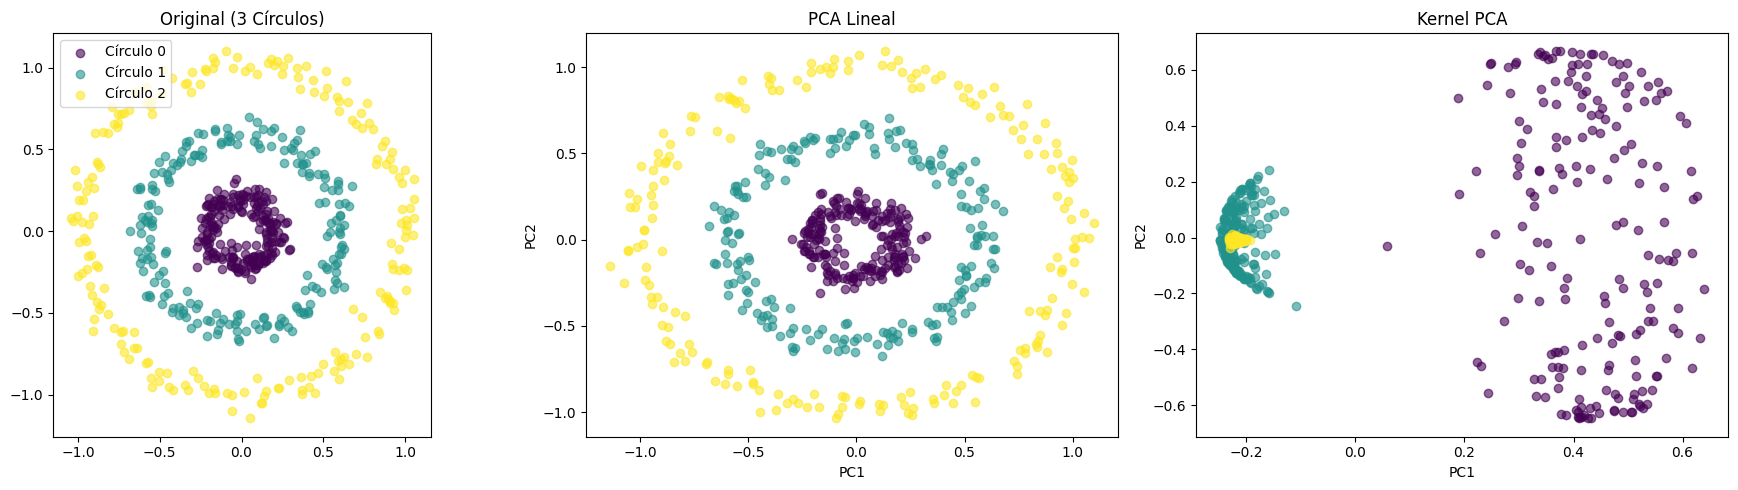

In [3]:
# Graficamos resultados
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
cmap = plt.colormaps['viridis'].resampled(N_CIRCLES) # Mapa de colores dinámico

# Función auxiliar para plotear
def plot_data(axis, data, labels, title):
    for i in range(N_CIRCLES):
        axis.scatter(data[labels==i, 0], data[labels==i, 1],
                     color=cmap(i), alpha=0.6, label=f'Círculo {i}')
    axis.set_title(title)
    if axis == ax[0]: axis.legend()

# Original
plot_data(ax[0], X, y, f"Original ({N_CIRCLES} Círculos)")
ax[0].set_aspect('equal')

# PCA
plot_data(ax[1], X_pca, y, "PCA Lineal")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")

# Kernel PCA
plot_data(ax[2], X_kpca, y, "Kernel PCA")
ax[2].set_xlabel("PC1")
ax[2].set_ylabel("PC2")

plt.tight_layout()
plt.show()